In [1]:
import pandas as pd
import glob
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:


# Define folder path
folder_path = "wishlists/adds.xlsx"


# Read all files into DataFrames and add filename column
adds = pd.read_excel(folder_path, skiprows=2)

adds.rename({"Selected Measure":"additions"}, axis=1, inplace=True)

In [3]:
folder_path = "wishlists/activations.xlsx"


activations  = pd.read_excel(folder_path, skiprows=2)

activations.rename({"Selected Measure":"activations"}, axis=1, inplace=True)

In [4]:
adds = adds.drop("Blank Measure", axis=1)
activations = activations.drop("Blank Measure", axis=1)

In [5]:
adds.drop_duplicates("product").to_clipboard()

In [6]:
folder_path = "wishlists/Annapurna Interactive Historical Revenues - releases_dates.csv"


dates  = pd.read_csv(folder_path)
dates = dates.dropna(subset='pc_release_date')

In [7]:
dates

,product,pc_release_date
0,Faraway,2025-12-31
1,Mixtape,2025-12-31
2,The Lost Wild,2026-11-01
3,Wheel World,2025-07-23
4,BattleSage,2025-06-30
5,to a T,2025-05-28
6,Skin Deep,2025-04-30
7,Lushfoil Photography Sim,2025-04-15
8,Wanderstop,2025-03-11
9,Morsels,2025-02-28


In [8]:
df = pd.merge(adds, activations, on=['product', 'Date'], how='left')

In [9]:
dates['product'].unique()

array(['Faraway', 'Mixtape', 'The Lost Wild', 'Wheel World', 'BattleSage',
       'to a T', 'Skin Deep', 'Lushfoil Photography Sim', 'Wanderstop',
       'Morsels', 'Flock', 'Lorelei and the Laser Eyes', 'Open Roads',
       'Thirsty Suitors', 'Cocoon', 'Storyteller', 'Solar Ash',
       'Hindsight', 'Hohokum', 'Stray', 'Neon White', 'A Memoir Blue',
       'The Pathless', 'The Artful Escape', 'Twelve Minutes', 'Last Stop',
       'Mundaun', 'Maquette', 'Wattam', 'Due Process', 'I Am Dead',
       'The Unfinished Swan', 'Outer Wilds', 'Journey', 'If Found...',
       'Florence', 'Kentucky Route Zero: TV Edition',
       'Sayonara Wild Hearts', 'Ashen', 'Telling Lies', 'Flower',
       'Donut County', 'Gorogoa', 'What Remains of Edith Finch'],
      dtype=object)

In [10]:
dates['pc_release_date'] = pd.to_datetime(dates['pc_release_date'])
df['release_date'] = pd.to_datetime(df['Date'])


In [11]:
release_date_dict = dates.groupby('product')['pc_release_date'].min().to_dict()

In [12]:
release_date_dict

{'A Memoir Blue': Timestamp('2022-03-24 00:00:00'),
 'Ashen': Timestamp('2019-12-09 00:00:00'),
 'BattleSage': Timestamp('2025-06-30 00:00:00'),
 'Cocoon': Timestamp('2023-09-29 00:00:00'),
 'Donut County': Timestamp('2018-08-28 00:00:00'),
 'Due Process': Timestamp('2020-11-03 00:00:00'),
 'Faraway': Timestamp('2025-12-31 00:00:00'),
 'Flock': Timestamp('2024-07-16 00:00:00'),
 'Florence': Timestamp('2020-02-13 00:00:00'),
 'Flower': Timestamp('2019-02-14 00:00:00'),
 'Gorogoa': Timestamp('2017-12-14 00:00:00'),
 'Hindsight': Timestamp('2022-08-04 00:00:00'),
 'Hohokum': Timestamp('2022-07-28 00:00:00'),
 'I Am Dead': Timestamp('2020-10-08 00:00:00'),
 'If Found...': Timestamp('2020-05-19 00:00:00'),
 'Journey': Timestamp('2020-06-11 00:00:00'),
 'Kentucky Route Zero: TV Edition': Timestamp('2020-01-28 00:00:00'),
 'Last Stop': Timestamp('2021-07-22 00:00:00'),
 'Lorelei and the Laser Eyes': Timestamp('2024-05-16 00:00:00'),
 'Lushfoil Photography Sim': Timestamp('2025-04-15 00:00:00'

In [13]:
df['release_date'] = df['product'].map(release_date_dict)


In [14]:
df["DBR"] = (df["Date"] - df["release_date"]).dt.days


In [15]:
df["Weeks_from_Release"] = (df["DBR"] // 7) + 1  # Week 1 starts at 0-7 days


In [16]:
df['cumulative_additions'] = df.groupby('product')['additions'].cumsum()
df['cumulative_activations'] = df.groupby('product')['activations'].cumsum()


In [17]:
df['cumulative_act_rate'] = df['cumulative_activations'] / df['cumulative_additions']
df['act_rate'] = df['activations'] / df['additions']

In [18]:
df.drop_duplicates(subset='product', keep='last').sort_values(by='cumulative_additions', ascending=False)

,Date,product,additions,activations,release_date,DBR,Weeks_from_Release,cumulative_additions,cumulative_activations,cumulative_act_rate,act_rate
132122,2025-05-15,Stray,2261,171,2022-07-19,1031.0,148.0,10386158,2722974,0.262173,0.075630
132115,2025-05-15,Outer Wilds,3267,204,2020-06-18,1792.0,257.0,4693823,1453238,0.309606,0.062443
132104,2025-05-15,Journey,408,18,2020-06-11,1799.0,258.0,1829207,701422,0.383457,0.044118
132134,2025-05-15,What Remains of Edith Finch,702,52,2017-04-25,2942.0,421.0,1804101,807702,0.447703,0.074074
132113,2025-05-15,Neon White,230,18,2022-06-16,1064.0,153.0,1210880,273071,0.225515,0.078261
132130,2025-05-15,Twelve Minutes,123,3,2021-08-19,1365.0,196.0,1158837,173252,0.149505,0.024390
132121,2025-05-15,Storyteller,210,37,2023-03-23,784.0,113.0,935055,186827,0.199803,0.176190
132091,2025-05-15,Cocoon,189,3,2023-09-29,594.0,85.0,929768,140787,0.151422,0.015873
132086,2025-05-15,Ashen,196,0,2019-12-09,1984.0,284.0,734200,112643,0.153423,0.000000
132099,2025-05-15,Gorogoa,152,11,2017-12-14,2709.0,388.0,702795,316465,0.450295,0.072368


In [19]:

#df['release_date'] = df.groupby('product')['release_date'].transform('min')
#df_combined["DAR"] = df_combined["DAR"].clip(lower=0)


#df = df.query("0 <= Weeks_from_Release <=12")

#df = df.query("'1/1/2015' <= release_date <='1/1/2026'")

#df = df.groupby(["product",'Date', "Weeks_from_Release"], as_index=False)["units"].max()
df = df.groupby(["product", "Weeks_from_Release"], as_index=False)[["additions", 'cumulative_additions','cumulative_activations','act_rate', 'cumulative_act_rate']].max()

In [20]:
df['product'].unique()

array(['A Memoir Blue', 'Ashen', 'BattleSage', 'Cocoon', 'Donut County',
       'Due Process', 'Faraway', 'Flock', 'Florence', 'Flower', 'Gorogoa',
       'Hindsight', 'Hohokum', 'I Am Dead', 'If Found...', 'Journey',
       'Kentucky Route Zero: TV Edition', 'Last Stop',
       'Lorelei and the Laser Eyes', 'Lushfoil Photography Sim',
       'Maquette', 'Mixtape', 'Morsels', 'Mundaun', 'Neon White',
       'Open Roads', 'Outer Wilds', 'Sayonara Wild Hearts', 'Skin Deep',
       'Solar Ash', 'Storyteller', 'Stray', 'Telling Lies',
       'The Artful Escape', 'The Lost Wild', 'The Pathless',
       'The Unfinished Swan', 'Thirsty Suitors', 'Twelve Minutes',
       'Wanderstop', 'Wattam', 'What Remains of Edith Finch',
       'Wheel World', 'to a T'], dtype=object)

In [21]:
title = 'to a T'

In [22]:
df.query("product==@title")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
16049,to a T,-386.0,0,0,0,NaN,NaN
16050,to a T,-385.0,0,0,0,NaN,NaN
16051,to a T,-384.0,0,0,0,NaN,NaN
16052,to a T,-383.0,0,0,0,NaN,NaN
16053,to a T,-382.0,0,0,0,NaN,NaN
...,...,...,...,...,...,...,...
16430,to a T,-5.0,46,27891,0,0.0,0.0
16431,to a T,-4.0,120,28330,0,0.0,0.0
16432,to a T,-3.0,373,30126,0,0.0,0.0
16433,to a T,-2.0,169,30884,0,0.0,0.0


In [23]:
current_cume = df.query("product==@title")['cumulative_additions'].values[-1]
current_week = df.query("product==@title")['Weeks_from_Release'].values[-1]

In [24]:
current_week

-1.0

In [25]:
title_df = df.query("product==@title")

In [26]:
title_df

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
16049,to a T,-386.0,0,0,0,NaN,NaN
16050,to a T,-385.0,0,0,0,NaN,NaN
16051,to a T,-384.0,0,0,0,NaN,NaN
16052,to a T,-383.0,0,0,0,NaN,NaN
16053,to a T,-382.0,0,0,0,NaN,NaN
...,...,...,...,...,...,...,...
16430,to a T,-5.0,46,27891,0,0.0,0.0
16431,to a T,-4.0,120,28330,0,0.0,0.0
16432,to a T,-3.0,373,30126,0,0.0,0.0
16433,to a T,-2.0,169,30884,0,0.0,0.0


In [93]:
ranked_df = df.query("Weeks_from_Release ==-1").sort_values(by='cumulative_additions', ascending=False)

In [95]:
range = 0.50

high_end = current_cume * (1 + range)
low_end = current_cume * (1 - range)

In [97]:
low_end

15526.5

In [99]:
df_filtered = ranked_df[~ranked_df['product'].str.contains('Soundtrack', case=False, na=False)]
df_filtered.query("additions>0")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
11656,Stray,-1.0,52206,2458525,141327,0.204286,0.057484
9617,Outer Wilds,-1.0,1084,407893,3,0.000000,0.000007
485,Ashen,-1.0,350,234635,9,0.000000,0.000039
14880,Wanderstop,-1.0,9542,225047,0,0.000000,0.000000
14308,Twelve Minutes,-1.0,1309,187333,10,0.002817,0.000053
11305,Storyteller,-1.0,729,163088,0,0.000000,0.000000
7168,Lushfoil Photography Sim,-1.0,1180,140498,2,0.000000,0.000015
10904,Solar Ash,-1.0,591,126256,11483,0.011869,0.092544
5551,Journey,-1.0,2447,105446,0,0.000000,0.000000
9428,Open Roads,-1.0,297,101608,1,0.000000,0.000010


In [101]:
df_filtered.query("@low_end < cumulative_additions <@high_end")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
14037,Thirsty Suitors,-1.0,102,44597,60,0.000000,0.001359
13163,The Pathless,-1.0,356,43032,3166,0.021429,0.076080
15045,Wattam,-1.0,159,38623,4,0.017544,0.000104
6734,Lorelei and the Laser Eyes,-1.0,310,35151,0,0.000000,0.000000
8319,Morsels,-1.0,62,34638,3,0.000000,0.000087
11890,Telling Lies,-1.0,648,33022,8,0.002695,0.000253
12382,The Artful Escape,-1.0,175,33003,8,0.046875,0.000242
16434,to a T,-1.0,90,31053,0,0.000000,0.000000
6201,Last Stop,-1.0,71,25007,5,0.021277,0.000202
7339,Maquette,-1.0,128,24384,4,0.000000,0.000168


In [103]:
df_filtered['pct_rank'] = df_filtered['cumulative_additions'].rank(pct=True)

In [105]:
df_filtered

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate,pct_rank
11656,Stray,-1.0,52206,2458525,141327,0.204286,0.057484,1.000000
9617,Outer Wilds,-1.0,1084,407893,3,0.000000,0.000007,0.972222
485,Ashen,-1.0,350,234635,9,0.000000,0.000039,0.944444
14880,Wanderstop,-1.0,9542,225047,0,0.000000,0.000000,0.916667
14308,Twelve Minutes,-1.0,1309,187333,10,0.002817,0.000053,0.888889
11305,Storyteller,-1.0,729,163088,0,0.000000,0.000000,0.861111
7168,Lushfoil Photography Sim,-1.0,1180,140498,2,0.000000,0.000015,0.833333
10904,Solar Ash,-1.0,591,126256,11483,0.011869,0.092544,0.805556
5551,Journey,-1.0,2447,105446,0,0.000000,0.000000,0.777778
9428,Open Roads,-1.0,297,101608,1,0.000000,0.000010,0.750000


In [107]:
df_filtered.query("product==@title")

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate,pct_rank
16434,to a T,-1.0,90,31053,0,0.0,0.0,0.388889


In [ ]:
stop

## Wishlist Activation Rates over time.

In [110]:
df = df[~df['product'].str.contains('Soundtrack', case=False, na=False)]


In [112]:
act_rate_df = df.query("Weeks_from_Release >=1")

In [114]:
#act_rate_df["DAR"] = act_rate_df.groupby("product")["DAR"].transform(lambda x: x.clip(lower=0))


In [116]:
act_rate_df

,product,Weeks_from_Release,additions,cumulative_additions,cumulative_activations,act_rate,cumulative_act_rate
221,A Memoir Blue,1.0,1682,20020,925,0.261538,0.046204
222,A Memoir Blue,2.0,327,22105,1059,0.113497,0.048436
223,A Memoir Blue,3.0,365,24006,1151,0.064103,0.048284
224,A Memoir Blue,4.0,229,25382,1238,0.092683,0.048859
225,A Memoir Blue,5.0,175,26429,1320,0.136752,0.049945
...,...,...,...,...,...,...,...
15658,What Remains of Edith Finch,417.0,1319,1785223,804089,0.730071,0.450414
15659,What Remains of Edith Finch,418.0,964,1791064,806950,0.710074,0.450892
15660,What Remains of Edith Finch,419.0,951,1796347,807240,0.070381,0.450413
15661,What Remains of Edith Finch,420.0,926,1801707,807552,0.075676,0.449173


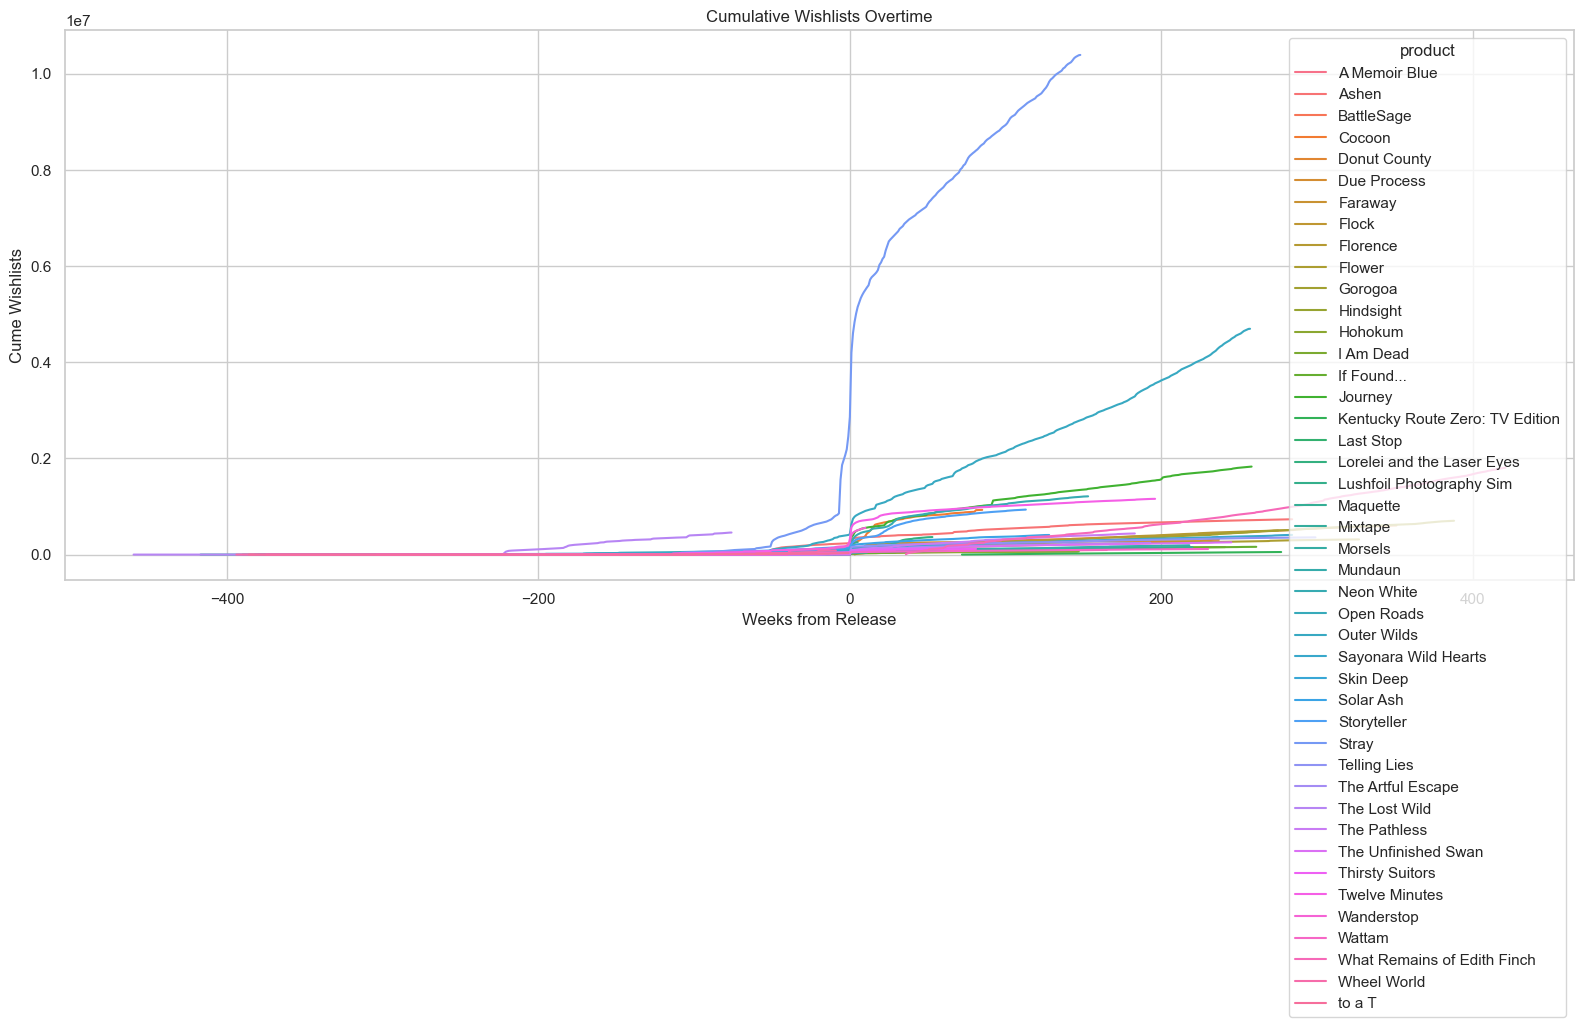

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=df, x="Weeks_from_Release", y="cumulative_additions", hue='product')

# Adding titles and labels
plt.title("Cumulative Wishlists Overtime")
plt.xlabel("Weeks from Release")
plt.ylabel("Cume Wishlists")

# Show the plot
plt.tight_layout()
plt.show()

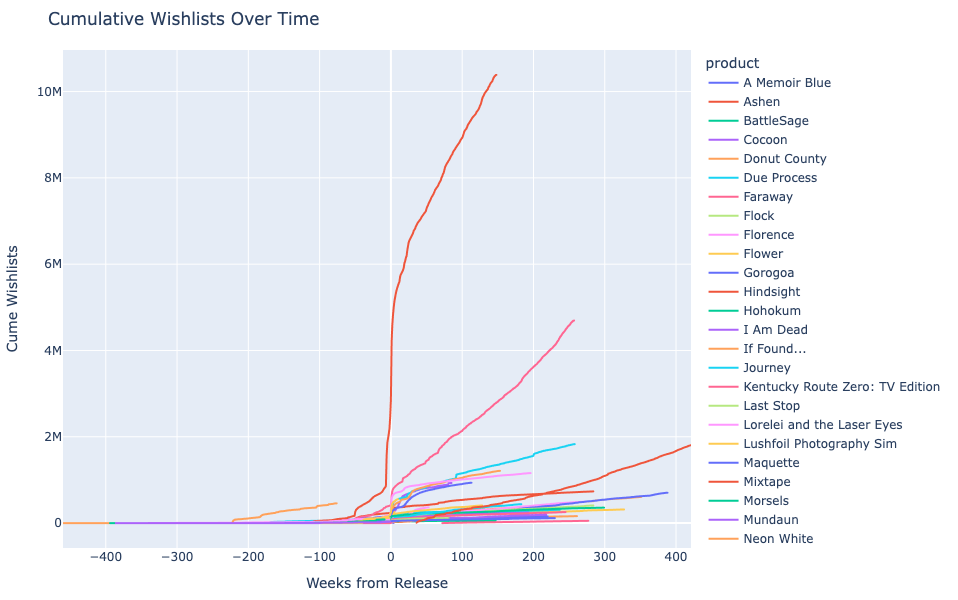

In [119]:
import plotly.express as px

# Create the interactive line plot
fig = px.line(df, 
              x="Weeks_from_Release", 
              y="cumulative_additions", 
              color='product',
              title="Cumulative Wishlists Over Time",
              labels={
                  "Weeks_from_Release": "Weeks from Release",
                  "cumulative_additions": "Cume Wishlists"
              })

# Update the layout for better aesthetics
fig.update_layout(
    autosize=True,
    height=600,
    margin=dict(l=20, r=20, t=50, b=20),
    hovermode='closest'
)

# Save as HTML
fig.write_html("docs/cumulative_wishlists_overtime.html")

# Show the interactive plot
fig.show()

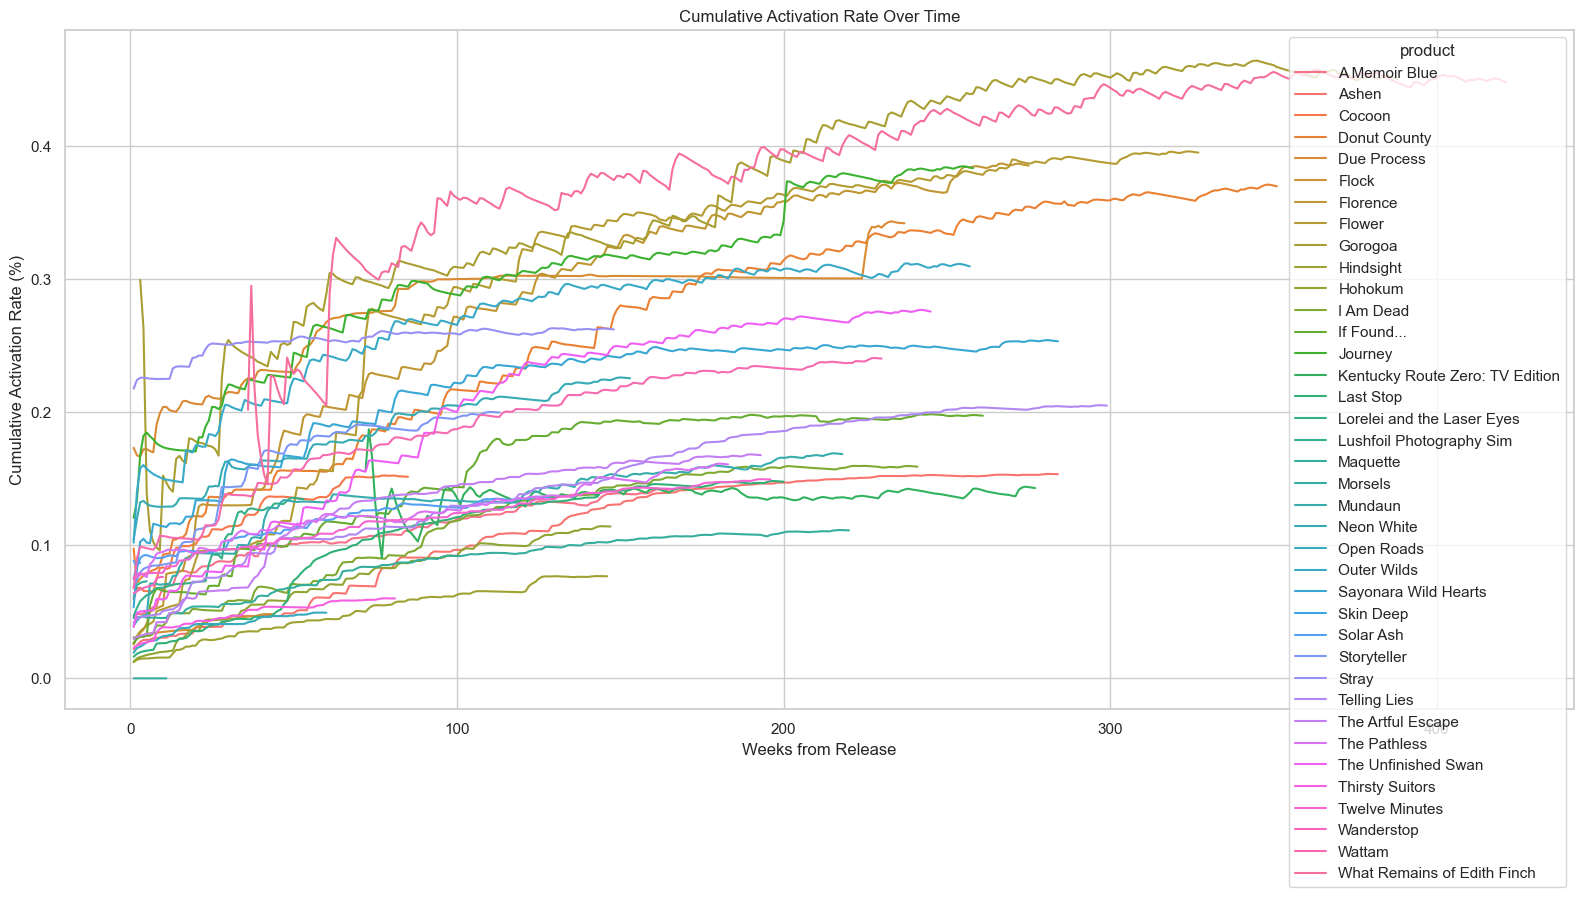

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=act_rate_df, x="Weeks_from_Release", y="cumulative_act_rate", hue='product')


# Adding titles and labels
plt.title("Cumulative Activation Rate Over Time")
plt.xlabel("Weeks from Release")
plt.ylabel("Cumulative Activation Rate (%)")

# Show the plot
plt.tight_layout()
plt.show()

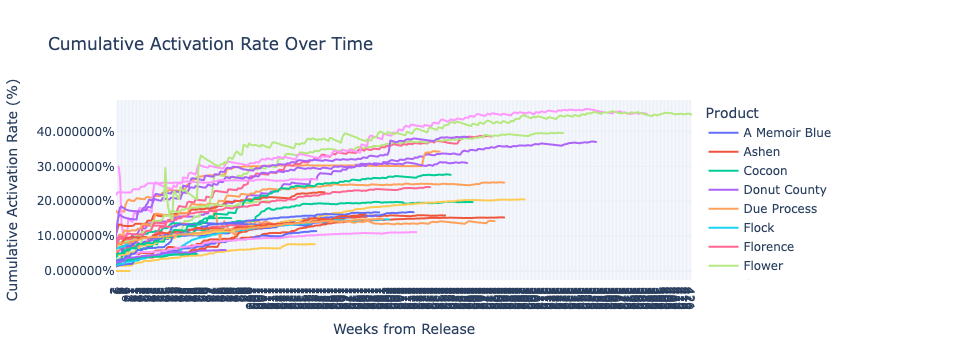

In [122]:
import plotly.express as px

# Create the Plotly line plot
fig = px.line(
    act_rate_df,
    x="Weeks_from_Release",
    y="cumulative_act_rate",
    color='product',
    title="Cumulative Activation Rate Over Time",
    labels={
        "Weeks_from_Release": "Weeks from Release",
        "cumulative_act_rate": "Cumulative Activation Rate (%)"
    },
    template='plotly_white'
)

# Improve layout for readability
fig.update_layout(
    legend_title_text='Product',
    xaxis=dict(tickmode='linear'),
    yaxis_tickformat='%'
)

# Display the plot
fig.show()

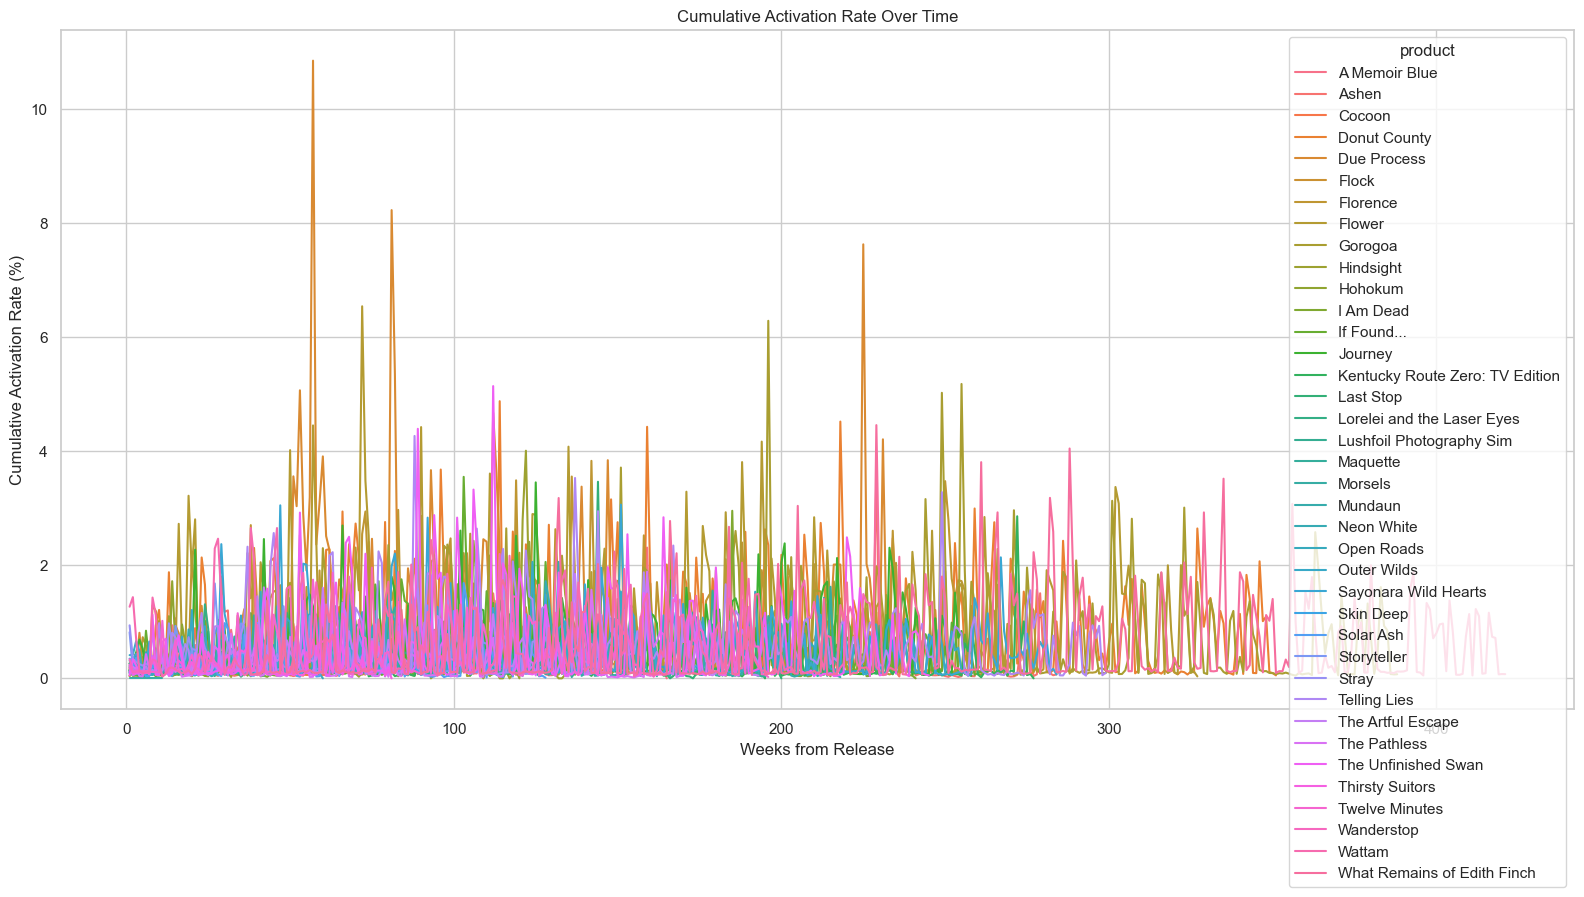

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=act_rate_df, x="Weeks_from_Release", y="act_rate", hue='product')

#plt.ylim(1,25)

# Adding titles and labels
plt.title("Cumulative Activation Rate Over Time")
plt.xlabel("Weeks from Release")
plt.ylabel("Cumulative Activation Rate (%)")

# Show the plot
plt.tight_layout()
plt.show()